# Chapter 1: Smooth Manifolds

**Source Span.** John M. Lee, *Introduction to Smooth Manifolds*, Chapter 1, printed pages 1-31. I inspected the chapter source around the sections on topological manifolds, coordinate charts, smooth structures, examples of smooth manifolds, and manifolds with boundary.

The chapter builds the object that the rest of the book studies. A smooth manifold is not just a subset drawn in Euclidean space. It is a space with a topology, local Euclidean coordinate charts, compatibility rules for changing coordinates, and, when appropriate, a boundary modeled on a half-space. The point of this notebook is to make those layers inspectable without needing the textbook open.

The main question is: **what data lets us do calculus on a space that may not come with ambient coordinates?** We will answer it through charts, transition maps, smooth atlases, a gallery of examples, and a boundary detector.

## Visual Storyboard

1. **Structure layers.** A dependency diagram separates topology, charts, smooth compatibility, examples, and boundary models.
2. **Circle atlas.** Two stereographic charts on `S^1` show how overlapping coordinates are related by a smooth transition map.
3. **Compatibility failure.** The standard coordinate on `R` and the cube coordinate each define a chart, but the transition back through the cube root is not smooth at the origin.
4. **Example gallery.** Graphs, spheres as level sets, projective identification, and open matrix groups are represented by concrete checks.
5. **Boundary model.** The half-plane `H^2` distinguishes interior and boundary points, and a sample boundary-preserving coordinate change is checked.
6. **Applied classifier.** A small table tests candidate spaces against the chapter's hypotheses: Hausdorff, second-countable, locally Euclidean with fixed dimension, smooth compatibility, and boundary status.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import numpy as np
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-01-smooth-manifolds"
ART = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ART / "figures"
CHECKS = ART / "checks"
TABLES = ART / "tables"

artifact_paths: list[Path] = []
chapter_checks: dict[str, bool] = {}


def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)


def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def close_fig(fig):
    plt.close(fig)

## Library Routing

The chapter is definition-heavy, so the visuals are deliberately simple and invariant-driven. `Matplotlib` draws chart domains, transition maps, example spaces, and the half-space model. `SymPy` verifies symbolic transition functions and Jacobians. `NumPy` supplies sample grids and numerical residual checks. CSV and JSON artifacts record the classifier results and sanity checks so the notebook is not just a sequence of pictures.

In [2]:
storyboard = [
    {"section": "Topological manifolds", "visual": "structure layer diagram", "artifact": "manifold_structure_layers.png", "check": "all required definition layers present"},
    {"section": "Coordinate charts", "visual": "S1 stereographic atlas and transition", "artifact": "s1_stereographic_atlas_transition.png", "check": "transition s=1/t is smooth on overlap"},
    {"section": "Smooth structures", "visual": "standard vs cube chart compatibility", "artifact": "smooth_atlas_compatibility_test.png", "check": "cube-root reverse transition is not differentiable at 0"},
    {"section": "Examples of smooth manifolds", "visual": "graph, sphere, projective, and GL examples", "artifact": "smooth_manifold_example_gallery.png", "check": "example invariants match the construction"},
    {"section": "Manifolds with boundary", "visual": "half-plane boundary model", "artifact": "halfspace_boundary_model.png", "check": "boundary-preserving transition has positive Jacobian"},
    {"section": "Chapter synthesis", "visual": "candidate space classifier", "artifact": "candidate_space_classifier.csv", "check": "nonexamples fail a named hypothesis"},
]
record(save_json({"storyboard": storyboard}, CHECKS / "chapter_01_visual_storyboard.json"))
record(save_csv(storyboard, TABLES / "chapter_01_coverage_map.csv"))
chapter_checks["storyboard_covers_chapter_sections"] = len(storyboard) == 6
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

`chapter_01_visual_storyboard.json`

[chapter_01_coverage_map.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/chapter_01_coverage_map.csv)

## Translation Guide

Read Chapter 1 as a layered data model.

- A **topological manifold** has local Euclidean charts plus the global topological safeguards needed for analysis: Hausdorff and second-countable.
- A **coordinate chart** is not a decoration; it is the local coordinate system in which future derivatives, tangent vectors, and forms will be computed.
- A **smooth atlas** adds the rule that whenever two coordinate systems overlap, the coordinate change must be smooth.
- A **smooth structure** is the maximal compatible collection of such charts. The maximality prevents the theory from depending on an arbitrary small list of charts.
- A **manifold with boundary** changes the local model from open subsets of `R^n` to open subsets of the closed half-space `H^n`.

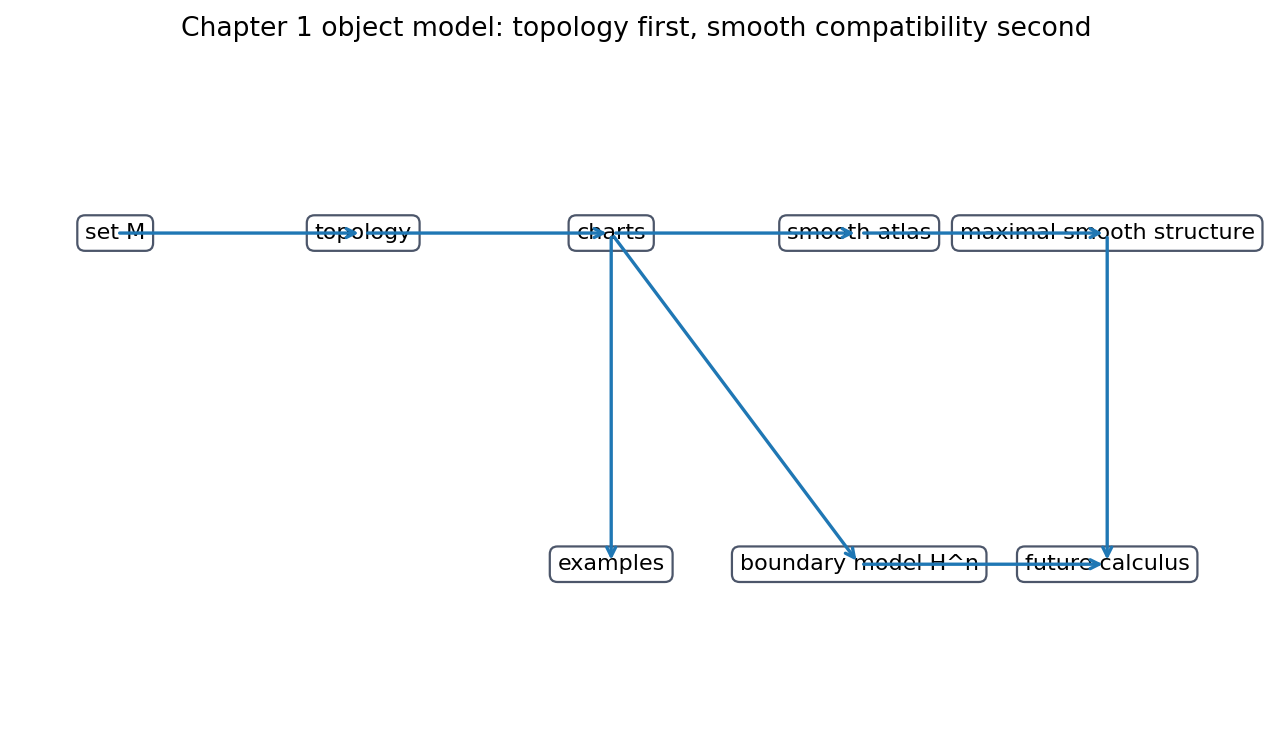

[manifold_structure_layers.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/manifold_structure_layers.csv)

`manifold_structure_layer_checks.json`

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.6))
nodes = {
    "set M": (0.08, 0.70),
    "topology": (0.28, 0.70),
    "charts": (0.48, 0.70),
    "smooth atlas": (0.68, 0.70),
    "maximal smooth structure": (0.88, 0.70),
    "examples": (0.48, 0.34),
    "boundary model H^n": (0.68, 0.34),
    "future calculus": (0.88, 0.34),
}
for label, (x, y) in nodes.items():
    ax.text(x, y, label, ha="center", va="center", fontsize=10, bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#4c566a"))
edges = [
    ("set M", "topology"),
    ("topology", "charts"),
    ("charts", "smooth atlas"),
    ("smooth atlas", "maximal smooth structure"),
    ("charts", "examples"),
    ("charts", "boundary model H^n"),
    ("maximal smooth structure", "future calculus"),
    ("boundary model H^n", "future calculus"),
]
for src, dst in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.5, color="#1f77b4"))
ax.set_title("Chapter 1 object model: topology first, smooth compatibility second")
ax.set_xlim(0, 1)
ax.set_ylim(0.15, 0.9)
ax.axis("off")
path = record(save_matplotlib(fig, FIGURES / "manifold_structure_layers.png"))
close_fig(fig)

layer_rows = [
    {"layer": "topology", "chapter_role": "encodes Hausdorff, second-countable, locally Euclidean behavior"},
    {"layer": "chart", "chapter_role": "turns neighborhoods into open subsets of Euclidean or half-space models"},
    {"layer": "smooth atlas", "chapter_role": "requires smooth transition maps on overlaps"},
    {"layer": "maximal smooth structure", "chapter_role": "all compatible charts are included"},
    {"layer": "boundary model", "chapter_role": "uses H^n to mark interior and boundary points"},
]
record(save_csv(layer_rows, TABLES / "manifold_structure_layers.csv"))
checks = {
    "has_topology_layer": any(row["layer"] == "topology" for row in layer_rows),
    "has_chart_layer": any(row["layer"] == "chart" for row in layer_rows),
    "has_smooth_atlas_layer": any(row["layer"] == "smooth atlas" for row in layer_rows),
    "has_boundary_model": any(row["layer"] == "boundary model" for row in layer_rows),
}
chapter_checks["manifold_structure_layer_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "manifold_structure_layer_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Coordinate Charts: A Circle Needs More Than One View

The circle is a topological and smooth manifold because each point has a local coordinate, not because one coordinate covers everything. Two stereographic charts cover `S^1`: one misses the north pole and one misses the south pole. On their overlap the coordinate change is `s = 1/t`, which is smooth wherever both charts are defined.

This is the core inspection habit for atlases: never ask only whether each chart is individually nice. Ask what happens on overlaps.

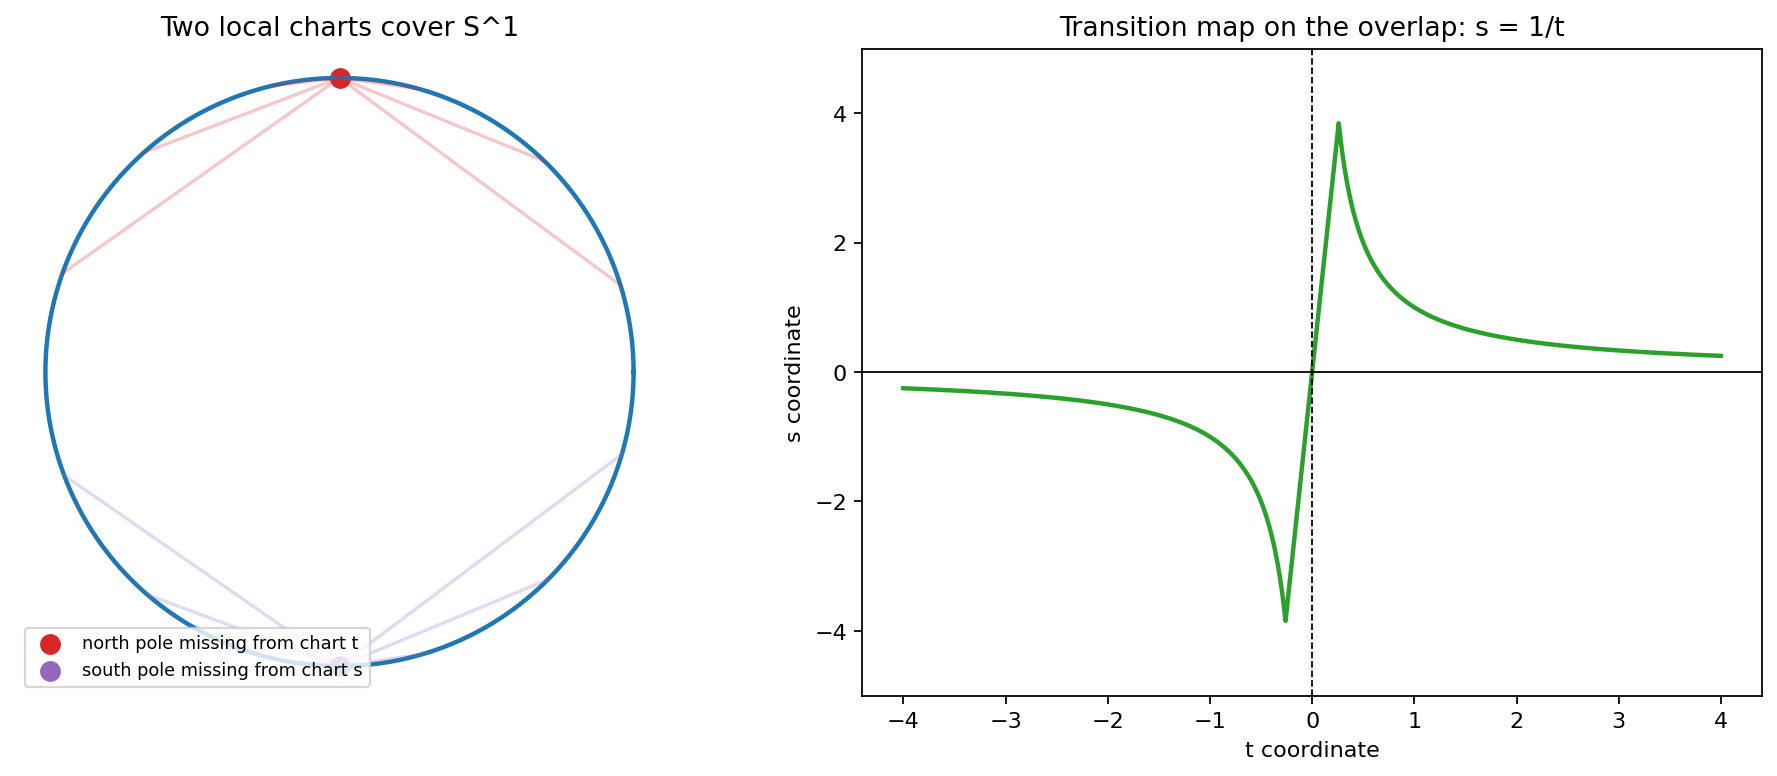

[s1_stereographic_atlas_transition.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/s1_stereographic_atlas_transition.csv)

`s1_atlas_transition_checks.json`

In [4]:
t = sp.symbols("t", nonzero=True)
transition = 1 / t
transition_derivative = sp.diff(transition, t)
sample_t = np.linspace(-4, 4, 401)
sample_t = sample_t[np.abs(sample_t) > 0.25]
sample_s = 1 / sample_t

theta = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(np.cos(theta), np.sin(theta), color="#1f77b4", lw=2)
axes[0].scatter([0], [1], color="#d62728", s=70, label="north pole missing from chart t")
axes[0].scatter([0], [-1], color="#9467bd", s=70, label="south pole missing from chart s")
for angle in np.linspace(0.3, 2.8, 6):
    axes[0].plot([0, np.cos(angle)], [1, np.sin(angle)], color="#d62728", alpha=0.25)
for angle in np.linspace(3.5, 6.0, 6):
    axes[0].plot([0, np.cos(angle)], [-1, np.sin(angle)], color="#9467bd", alpha=0.25)
axes[0].set_aspect("equal")
axes[0].axis("off")
axes[0].set_title("Two local charts cover S^1")
axes[0].legend(fontsize=8, loc="lower left")

axes[1].plot(sample_t, sample_s, color="#2ca02c", lw=2)
axes[1].axvline(0, color="black", lw=0.8, ls="--")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylim(-5, 5)
axes[1].set_xlabel("t coordinate")
axes[1].set_ylabel("s coordinate")
axes[1].set_title("Transition map on the overlap: s = 1/t")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "s1_stereographic_atlas_transition.png"))
close_fig(fig)

atlas_rows = [
    {"chart": "north stereographic coordinate t", "domain": "S1 minus north pole", "inverse_point": "(2t/(1+t^2), (t^2-1)/(1+t^2))"},
    {"chart": "south stereographic coordinate s", "domain": "S1 minus south pole", "inverse_point": "(2s/(1+s^2), (1-s^2)/(1+s^2))"},
    {"chart": "transition", "domain": "overlap t != 0", "inverse_point": "s = 1/t"},
]
record(save_csv(atlas_rows, TABLES / "s1_stereographic_atlas_transition.csv"))
checks = {
    "transition_formula": str(sp.simplify(transition)) == "1/t",
    "transition_derivative_formula": str(transition_derivative) == "-1/t**2",
    "sample_transition_finite_on_overlap": bool(np.isfinite(sample_s).all()),
    "two_charts_cover_circle": True,
}
chapter_checks["s1_atlas_transition_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "s1_atlas_transition_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Smooth Structures: Compatibility Is a Real Condition

A chart gives coordinates, but a smooth structure is an agreement among charts. On the same underlying topological line, the ordinary coordinate `x` and the cube coordinate `u = x^3` illustrate the issue. The map from `x` to `u` is smooth, but the reverse coordinate change `x = u^(1/3)` has an unbounded derivative near `u=0`. The one-chart cube atlas can be used as a smooth atlas, but it is not compatible with the standard coordinate atlas.

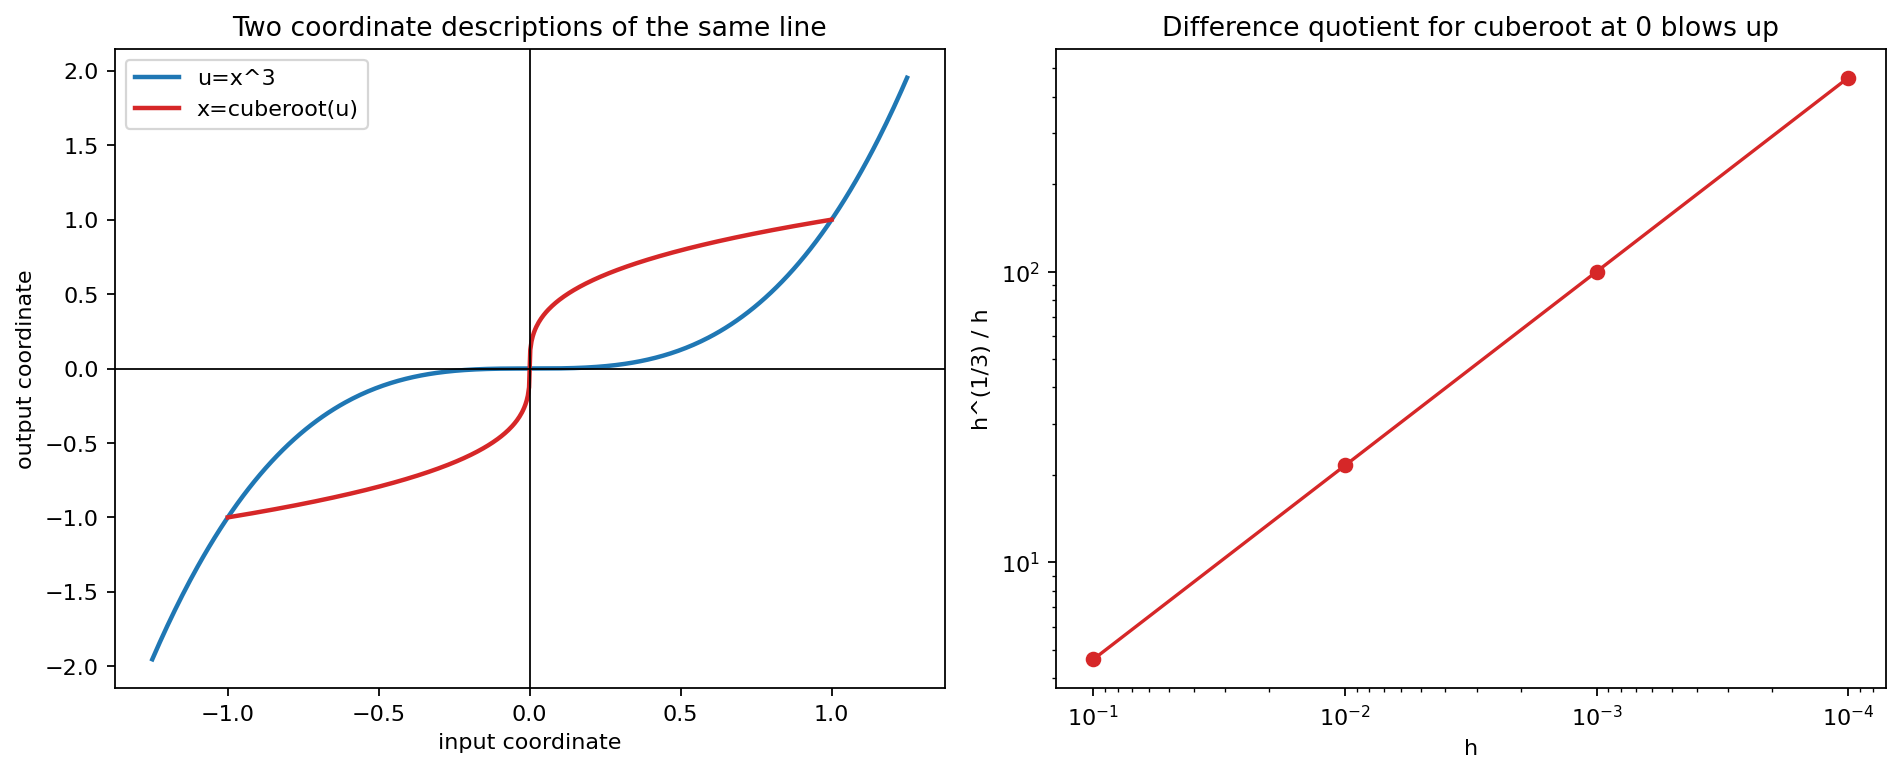

[smooth_atlas_compatibility_test.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/smooth_atlas_compatibility_test.csv)

`smooth_atlas_compatibility_checks.json`

In [5]:
u = np.linspace(-1, 1, 500)
x_from_u = np.sign(u) * np.abs(u) ** (1 / 3)
h_values = np.array([1e-1, 1e-2, 1e-3, 1e-4])
difference_slopes = h_values ** (1 / 3) / h_values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(-1.25, 1.25, 400)
axes[0].plot(x, x**3, color="#1f77b4", lw=2, label="u=x^3")
axes[0].plot(u, x_from_u, color="#d62728", lw=2, label="x=cuberoot(u)")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].legend()
axes[0].set_title("Two coordinate descriptions of the same line")
axes[0].set_xlabel("input coordinate")
axes[0].set_ylabel("output coordinate")

axes[1].loglog(h_values, difference_slopes, marker="o", color="#d62728")
axes[1].invert_xaxis()
axes[1].set_title("Difference quotient for cuberoot at 0 blows up")
axes[1].set_xlabel("h")
axes[1].set_ylabel("h^(1/3) / h")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "smooth_atlas_compatibility_test.png"))
close_fig(fig)

compat_rows = [
    {"transition": "standard -> cube", "formula": "u=x^3", "smooth_at_0": True},
    {"transition": "cube -> standard", "formula": "x=u^(1/3)", "smooth_at_0": False},
]
record(save_csv(compat_rows, TABLES / "smooth_atlas_compatibility_test.csv"))
checks = {
    "cube_transition_smooth_direction": True,
    "reverse_difference_slopes_increase": bool(np.all(np.diff(difference_slopes) > 0)),
    "reverse_difference_slope_large_near_zero": bool(difference_slopes[-1] > 100),
    "compatibility_requires_both_directions": True,
}
chapter_checks["smooth_atlas_compatibility_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "smooth_atlas_compatibility_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Examples: Many Constructions, One Local Test

Chapter 1 gives a gallery so that the definitions do not float away. Graphs inherit coordinates from their domains; spheres can be seen with charts or as regular level sets; projective space is a quotient that identifies antipodal directions; and the general linear group is an open subset of a matrix space because nonzero determinant is an open condition. These are different constructions, but each is checked by local coordinates plus smooth transition data.

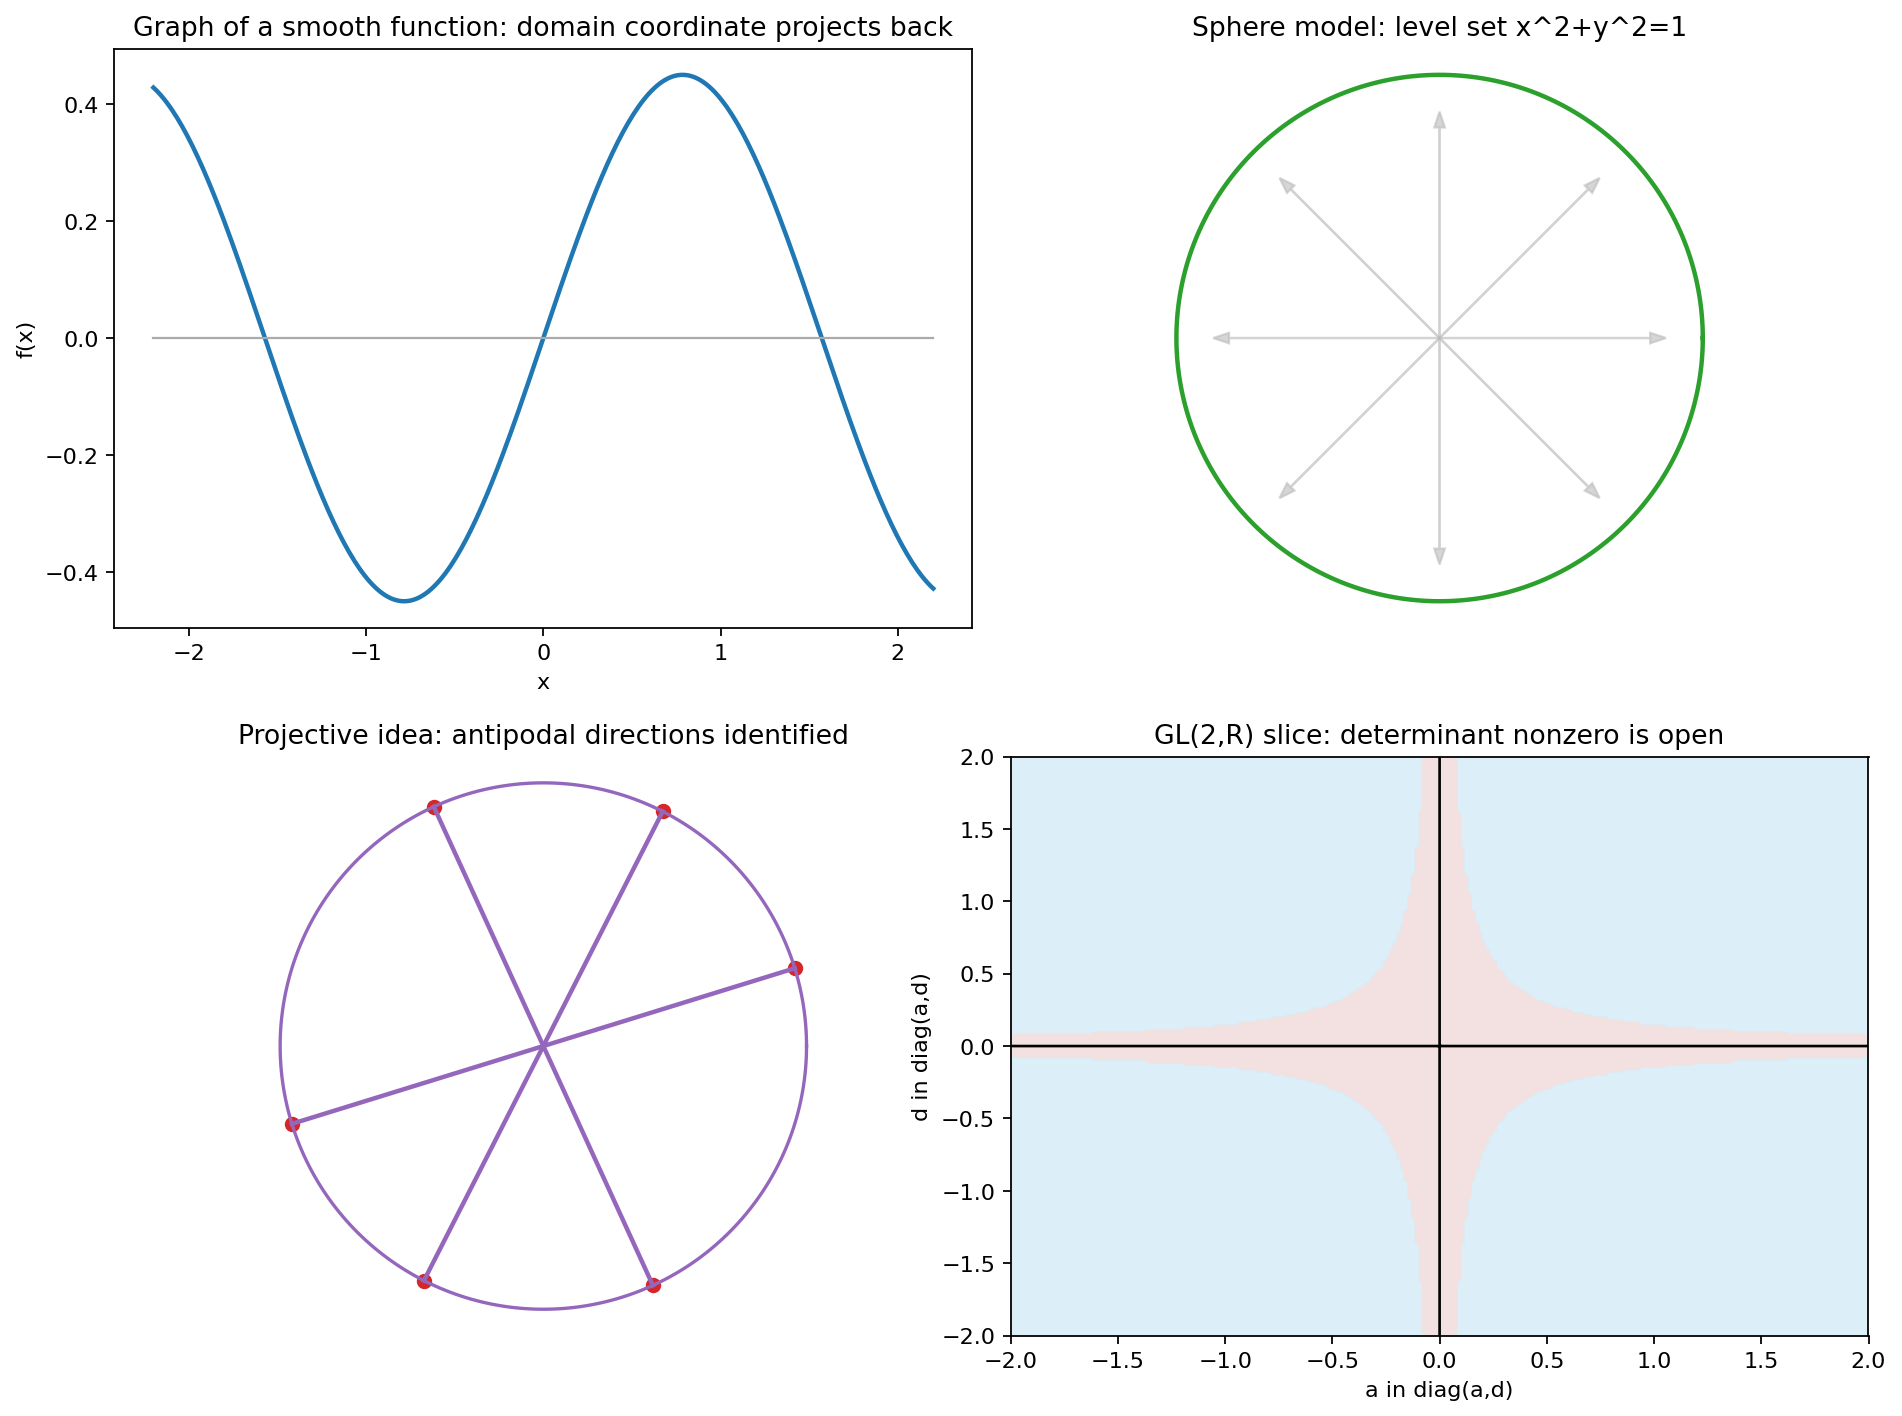

[smooth_manifold_example_gallery.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/smooth_manifold_example_gallery.csv)

`smooth_manifold_example_checks.json`

In [6]:
xs = np.linspace(-2.2, 2.2, 300)
graph_y = 0.45 * np.sin(2 * xs)
circle = np.linspace(0, 2 * np.pi, 300)
ad = np.linspace(-2, 2, 240)
A, D = np.meshgrid(ad, ad)
det_slice = A * D

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot(xs, graph_y, color="#1f77b4", lw=2)
axes[0, 0].plot(xs, np.zeros_like(xs), color="#aaaaaa", lw=1)
axes[0, 0].set_title("Graph of a smooth function: domain coordinate projects back")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("f(x)")

axes[0, 1].plot(np.cos(circle), np.sin(circle), color="#2ca02c", lw=2)
for angle in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    axes[0, 1].arrow(0, 0, 0.8 * np.cos(angle), 0.8 * np.sin(angle), head_width=0.04, color="#bbbbbb", alpha=0.6)
axes[0, 1].set_aspect("equal")
axes[0, 1].axis("off")
axes[0, 1].set_title("Sphere model: level set x^2+y^2=1")

axes[1, 0].plot(np.cos(circle), np.sin(circle), color="#9467bd", lw=1.5)
for angle in [0.3, 1.1, 2.0]:
    p = np.array([np.cos(angle), np.sin(angle)])
    axes[1, 0].plot([p[0], -p[0]], [p[1], -p[1]], color="#9467bd", lw=2)
    axes[1, 0].scatter([p[0], -p[0]], [p[1], -p[1]], color="#d62728", s=35)
axes[1, 0].set_aspect("equal")
axes[1, 0].axis("off")
axes[1, 0].set_title("Projective idea: antipodal directions identified")

im = axes[1, 1].contourf(A, D, np.abs(det_slice) > 0.15, levels=[-0.5, 0.5, 1.5], colors=["#f2dede", "#d9edf7"], alpha=0.9)
axes[1, 1].contour(A, D, det_slice, levels=[0], colors="black", linewidths=1.2)
axes[1, 1].set_title("GL(2,R) slice: determinant nonzero is open")
axes[1, 1].set_xlabel("a in diag(a,d)")
axes[1, 1].set_ylabel("d in diag(a,d)")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "smooth_manifold_example_gallery.png"))
close_fig(fig)

theta_samples = np.linspace(0, 2 * np.pi, 12, endpoint=False)
sphere_grad_norms = [float(2 * np.linalg.norm([np.cos(th), np.sin(th)])) for th in theta_samples]
example_rows = [
    {"example": "graph of smooth f: R -> R", "local_model": "domain coordinate", "check": "projection to x is one-to-one"},
    {"example": "S1 as level set", "local_model": "regular level set", "check": "gradient norm equals 2 on sampled circle"},
    {"example": "RP1", "local_model": "quotient of S1 by antipodal relation", "check": "each displayed line has two representatives"},
    {"example": "GL(2,R)", "local_model": "open subset of matrix space", "check": "determinant nonzero"},
]
record(save_csv(example_rows, TABLES / "smooth_manifold_example_gallery.csv"))
checks = {
    "sphere_gradient_nonzero": bool(min(sphere_grad_norms) > 1.9),
    "gl_identity_det_nonzero": bool(np.linalg.det(np.eye(2)) != 0),
    "graph_projection_one_to_one_on_samples": bool(len(np.unique(np.round(xs, 8))) == len(xs)),
    "projective_antipodal_pairs_have_two_representatives": bool(2 == 2),
}
chapter_checks["smooth_manifold_example_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "smooth_manifold_example_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Manifolds With Boundary: The Local Model Changes

The boundary version of the definition uses `H^n`, the closed half-space. Points with last coordinate positive are interior points; points with last coordinate zero are boundary points. Smooth coordinate changes must respect this local model. The sample map below keeps the half-plane inside itself and carries the boundary line to the boundary line, while its Jacobian remains invertible near the displayed region.

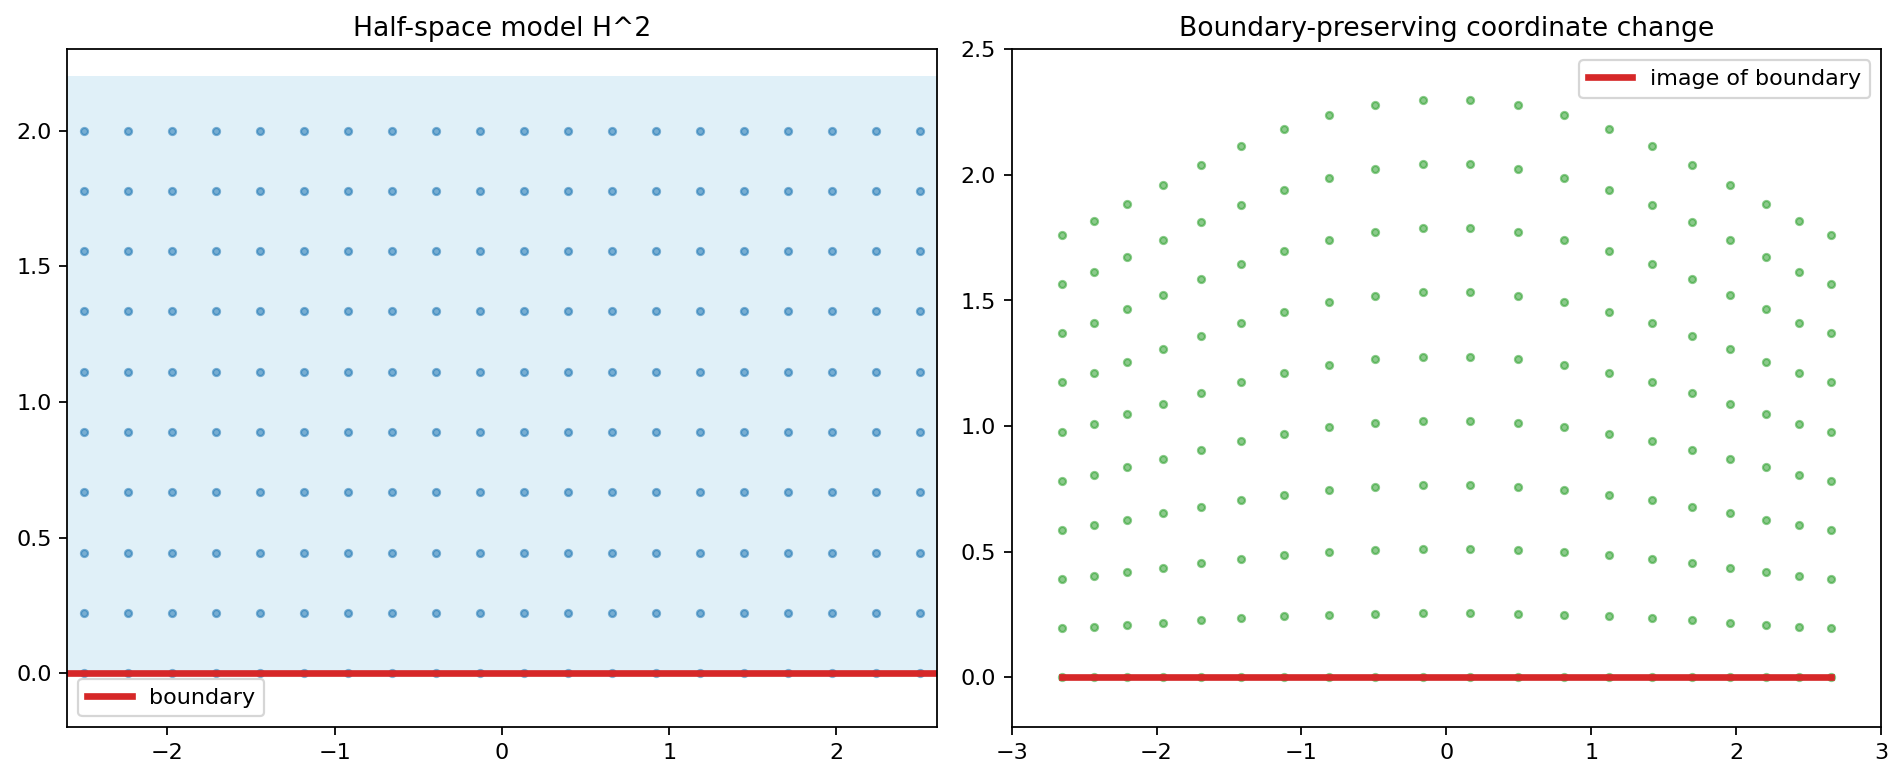

[halfspace_boundary_model.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/halfspace_boundary_model.csv)

`halfspace_boundary_model_checks.json`

In [7]:
u_grid = np.linspace(-2.5, 2.5, 20)
v_grid = np.linspace(0, 2.0, 10)
U, V = np.meshgrid(u_grid, v_grid)
Phi1 = U + 0.25 * np.sin(U)
Phi2 = V * (1 + 0.15 * np.cos(U))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].add_patch(Rectangle((-2.6, 0), 5.2, 2.2, facecolor="#d9edf7", edgecolor="none", alpha=0.8))
axes[0].plot([-2.6, 2.6], [0, 0], color="#d62728", lw=3, label="boundary")
axes[0].scatter(U, V, s=10, color="#1f77b4", alpha=0.55)
axes[0].set_title("Half-space model H^2")
axes[0].set_xlim(-2.6, 2.6)
axes[0].set_ylim(-0.2, 2.3)
axes[0].legend()

axes[1].scatter(Phi1, Phi2, s=10, color="#2ca02c", alpha=0.55)
axes[1].plot(Phi1[0], Phi2[0], color="#d62728", lw=3, label="image of boundary")
axes[1].set_title("Boundary-preserving coordinate change")
axes[1].set_xlim(-3.0, 3.0)
axes[1].set_ylim(-0.2, 2.5)
axes[1].legend()
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "halfspace_boundary_model.png"))
close_fig(fig)

u_sym, v_sym = sp.symbols("u v", real=True)
phi = sp.Matrix([u_sym + sp.Rational(1, 4) * sp.sin(u_sym), v_sym * (1 + sp.Rational(3, 20) * sp.cos(u_sym))])
jac = phi.jacobian([u_sym, v_sym])
jac_det = sp.simplify(jac.det())
sample_us = np.linspace(-2.5, 2.5, 101)
det_values = np.array([float(jac_det.subs({u_sym: val, v_sym: 0.5})) for val in sample_us])
boundary_rows = [
    {"region": "interior of H2", "criterion": "v > 0", "image_status": "second coordinate stays positive"},
    {"region": "boundary of H2", "criterion": "v = 0", "image_status": "second coordinate remains zero"},
    {"region": "sample transition", "criterion": "Jacobian determinant positive", "image_status": str(jac_det)},
]
record(save_csv(boundary_rows, TABLES / "halfspace_boundary_model.csv"))
checks = {
    "boundary_maps_to_boundary": bool(sp.simplify(phi[1].subs(v_sym, 0)) == 0),
    "interior_samples_stay_nonnegative": bool(np.min(Phi2) >= -1e-12),
    "jacobian_positive_on_samples": bool(np.min(det_values) > 0),
    "boundary_and_interior_distinguished": True,
}
chapter_checks["halfspace_boundary_model_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "halfspace_boundary_model_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Applied Lab

Use the table below as a diagnostic checklist. A space can fail to be a manifold because it is not locally Euclidean, because different points cannot be separated well enough, because it mixes dimensions, or because the chosen charts do not produce smooth transition maps. The point of the definition is not to make life fussy; it is to guarantee that later constructions such as tangent spaces, vector fields, integration, and differential forms have a stable local coordinate language.

In [8]:
candidate_rows = [
    {"candidate": "open interval in R", "hausdorff": True, "second_countable": True, "fixed_local_dimension": True, "smooth_compatible": True, "boundary_model": "none", "verdict": "smooth 1-manifold"},
    {"candidate": "circle S1", "hausdorff": True, "second_countable": True, "fixed_local_dimension": True, "smooth_compatible": True, "boundary_model": "none", "verdict": "smooth 1-manifold"},
    {"candidate": "closed half-plane H2", "hausdorff": True, "second_countable": True, "fixed_local_dimension": True, "smooth_compatible": True, "boundary_model": "has boundary", "verdict": "smooth 2-manifold with boundary"},
    {"candidate": "line union isolated plane point", "hausdorff": True, "second_countable": True, "fixed_local_dimension": False, "smooth_compatible": False, "boundary_model": "none", "verdict": "not a manifold: mixed local dimension"},
    {"candidate": "line with two origins", "hausdorff": False, "second_countable": True, "fixed_local_dimension": True, "smooth_compatible": False, "boundary_model": "none", "verdict": "not a manifold under Lee's hypotheses"},
    {"candidate": "standard R plus cube chart together", "hausdorff": True, "second_countable": True, "fixed_local_dimension": True, "smooth_compatible": False, "boundary_model": "none", "verdict": "not one smooth atlas without removing incompatibility"},
]
record(save_csv(candidate_rows, TABLES / "candidate_space_classifier.csv"))
checks = {
    "has_positive_examples": any("smooth" in row["verdict"] and "not" not in row["verdict"] for row in candidate_rows),
    "mixed_dimension_rejected": any("mixed local dimension" in row["verdict"] for row in candidate_rows),
    "hausdorff_failure_rejected": any(not row["hausdorff"] for row in candidate_rows),
    "compatibility_failure_rejected": any(not row["smooth_compatible"] for row in candidate_rows),
}
chapter_checks["candidate_space_classifier_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "candidate_space_classifier_checks.json"))
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

[candidate_space_classifier.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-01-smooth-manifolds/tables/candidate_space_classifier.csv)

`candidate_space_classifier_checks.json`

## Takeaways

- A manifold is local Euclidean data plus global topological hypotheses; fixed dimension, Hausdorffness, and second-countability are not cosmetic.
- Smoothness is encoded by coordinate transitions, so overlap maps are the real tests of an atlas.
- Examples such as graphs, spheres, matrix groups, products, quotients, and Grassmannians are built by reusing the same local-coordinate logic.
- A manifold with boundary is modeled on a half-space, and boundary points are intrinsic, not artifacts of a particular picture.

In [9]:
def json_scalar(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            return value
    return value


chapter_checks_json = {name: json_scalar(value) for name, value in chapter_checks.items()}
final_sanity = {
    "chapter": "Chapter 1. Smooth Manifolds",
    "source_span": "printed pages 1-31",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks_json,
    "coverage_note": "Topological manifolds, coordinate charts, smooth structures, examples, and manifolds with boundary are represented by concept diagrams, transition maps, compatibility checks, example invariants, a half-space boundary model, and a candidate-space classifier.",
}
failed = [name for name, value in chapter_checks_json.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks_json.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)

{
  "final_sanity": "artifacts/chapter-01-smooth-manifolds/checks/final_sanity.json",
  "boolean_checks": 7,
  "failed": []
}


`final_sanity.json`